In [ ]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from imblearn.combine import SMOTEENN
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
#Loading the dataset and doing exploratory analysis
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CST4215/CW1/dataset/bank-full.csv", sep=';')
print("The columns in the dataset are: ", df.columns)
print("\nThe datatypes of each column are: \n", df.dtypes)

# Checking the null values in the dataset
print("Null Values: \n", df.isnull().sum())
print("Na Values: \n", df.isna().sum())

The columns in the dataset are:  Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

The datatypes of each column are: 
 age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object
Null Values: 
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Na Values: 
 age          0
job          0
marital      0
education    0
default 

In [ ]:
# Print the summary statistics of the dataset
print("The Summary Statistics of the Numeric Variables in the dataset are: \n", df.describe())

print("\nThe size of the data set is: ", df.shape)

The Summary Statistics of the Numeric Variables in the dataset are: 
                 age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.00

In [ ]:
# Check the number of unknowns in the categorical variables
features_to_check = df[['job', 'education', 'contact', 'poutcome']]

for feature in features_to_check:
  unknown_count = df[feature].value_counts().get('unknown', 0)
  unknown_percent = unknown_count / len(df) * 100
  print(f"The number of unknown values in {feature} is: {unknown_count} and the percentage is {unknown_percent:.2f}%\n")

pday_counts = df['pdays'].value_counts()
never_contacted = pday_counts.get(-1, 0)
print(f"The number of never contacted customers is: {never_contacted}")

contacted = len(df) - never_contacted
print(f"The number of contacted customers is: {contacted}")

The number of unknown values in job is: 288 and the percentage is 0.64%

The number of unknown values in education is: 1857 and the percentage is 4.11%

The number of unknown values in contact is: 13020 and the percentage is 28.80%

The number of unknown values in poutcome is: 36959 and the percentage is 81.75%

The number of never contacted customers is: 36954
The number of contacted customers is: 8257


In [ ]:
# Divide the columns
numeric_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'contact', 'poutcome']
binary_features = ['default', 'housing', 'loan']

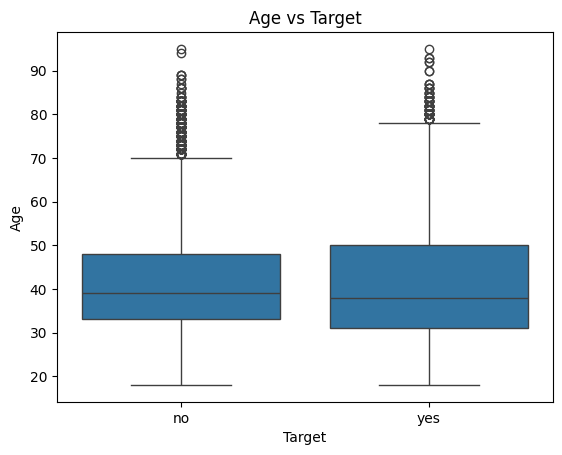

In [ ]:
# Check the distribution of age with whether they subscribed or not
age_vs_target = sns.boxplot(x="y", y="age", data=df)
age_vs_target.set_title("Age vs Target")
age_vs_target.set_xlabel("Target")
age_vs_target.set_ylabel("Age")
plt.show()

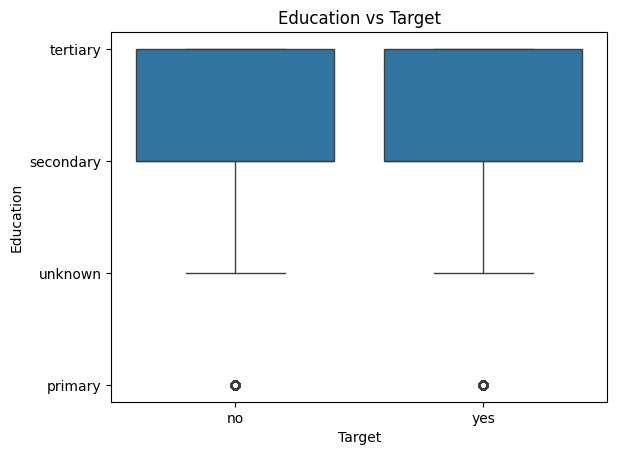

In [ ]:
# Check the distribution of education with whether they subscribed or not
age_vs_target = sns.boxplot(x="y", y="education", data=df)
age_vs_target.set_title("Education vs Target")
age_vs_target.set_xlabel("Target")
age_vs_target.set_ylabel("Education")
plt.show()

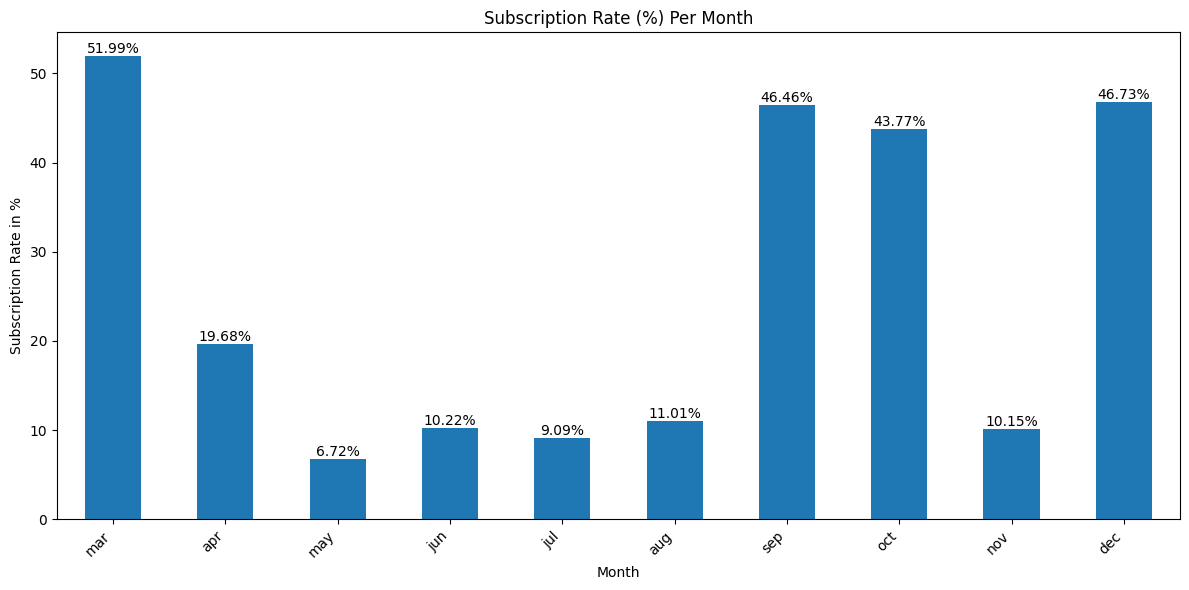

In [ ]:
# Calculate the subscription rate per month (how many people subscribed per month)
monthly_subscription_rate = df.groupby('month')['y'].value_counts(normalize=True).unstack() * 100

month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_subscription_rate = monthly_subscription_rate.reindex(month_order)

# Plot the monthly subscription rate
plt.figure(figsize=(12, 6))
sub_rate = monthly_subscription_rate['yes'].plot(kind='bar')

plt.xlabel('Month')
plt.ylabel('Subscription Rate in %')
plt.title('Subscription Rate (%) Per Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add values on top of each bar
for container in sub_rate.containers:
    sub_rate.bar_label(container, fmt='%.2f%%')

plt.show()

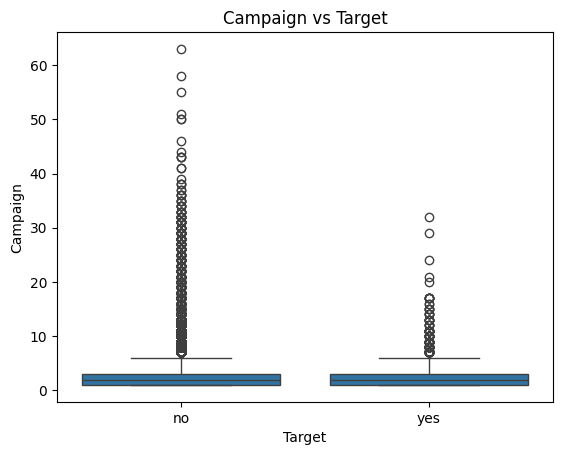

In [ ]:
# Check the distribution of campaign with whether they subscribed or not
campaigns = sns.boxplot(x='y', y='campaign', data=df)
campaigns.set_title("Campaign vs Target")
campaigns.set_xlabel("Target")
campaigns.set_ylabel("Campaign")
plt.show()

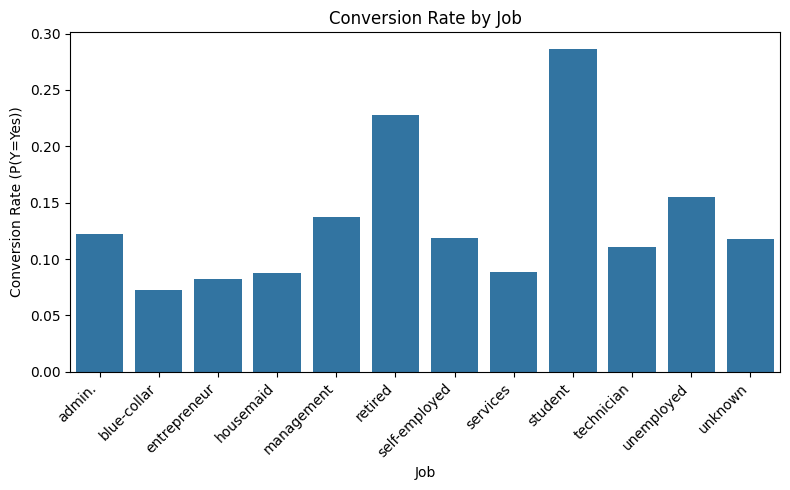


--- Conversion Rates for JOB --- 


job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: yes, dtype: float64


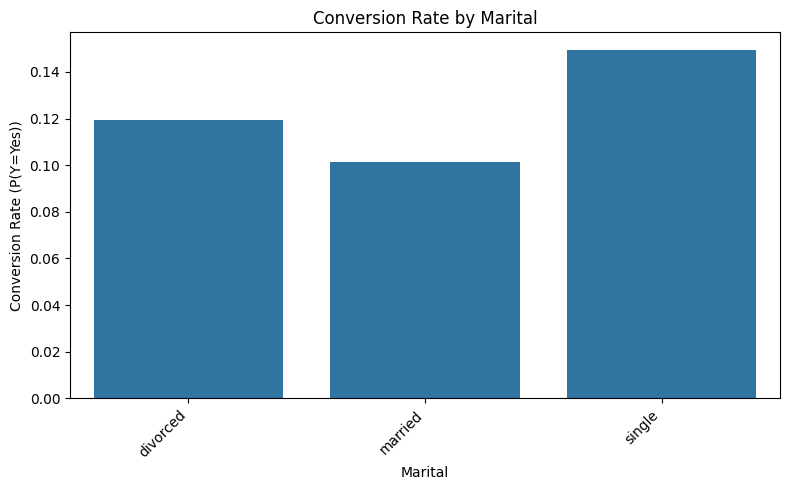


--- Conversion Rates for MARITAL --- 


marital
single      0.149492
divorced    0.119455
married     0.101235
Name: yes, dtype: float64


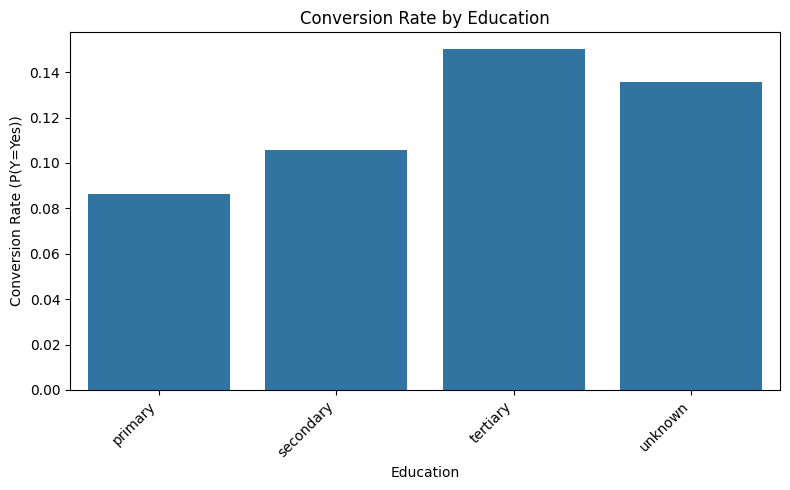


--- Conversion Rates for EDUCATION --- 


education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: yes, dtype: float64


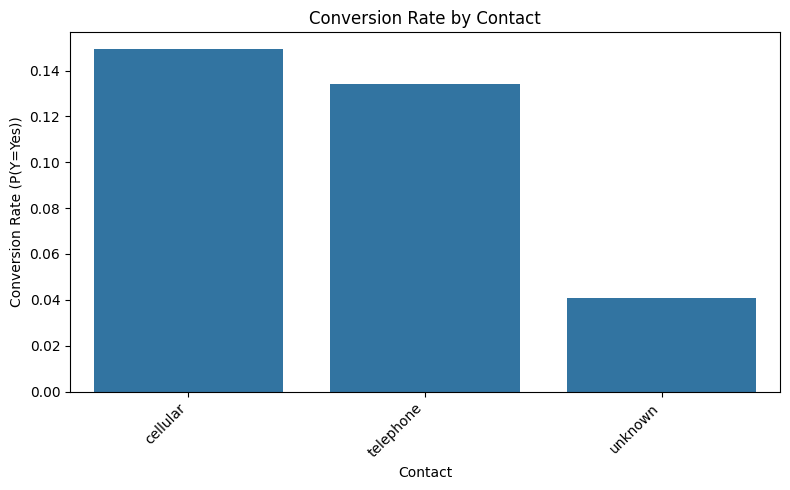


--- Conversion Rates for CONTACT --- 


contact
cellular     0.149189
telephone    0.134205
unknown      0.040707
Name: yes, dtype: float64


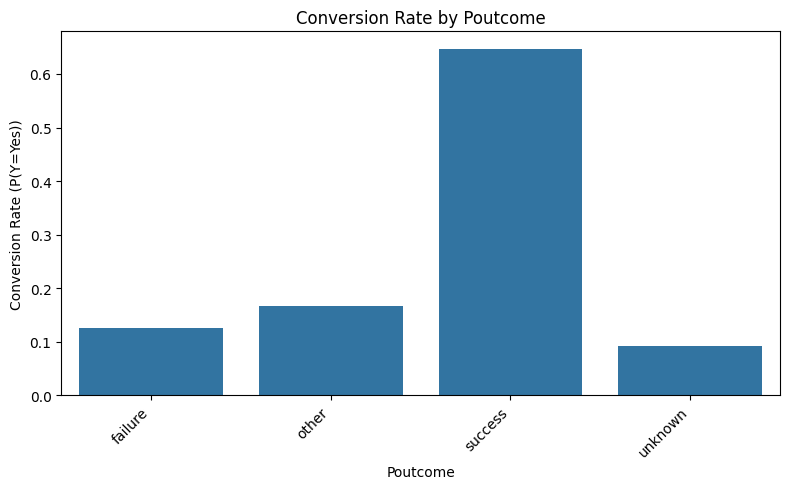


--- Conversion Rates for POUTCOME --- 


poutcome
success    0.647253
other      0.166848
failure    0.126097
unknown    0.091615
Name: yes, dtype: float64


In [ ]:
# See the split for all the categotrical features
for feature in categorical_features:
  rate_table = pd.crosstab(df[feature], df['y'], normalize='index')['yes']

  plt.figure(figsize=(8,5))
  sns.barplot(
      x=rate_table.index,
      y=rate_table.values
  )

  plt.title(f"Conversion Rate by {feature.title()}")
  plt.xlabel(feature.title())
  plt.ylabel("Conversion Rate (P(Y=Yes))")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

  print(f"\n--- Conversion Rates for {feature.upper()} --- \n\n")
  print(rate_table.sort_values(ascending=False))

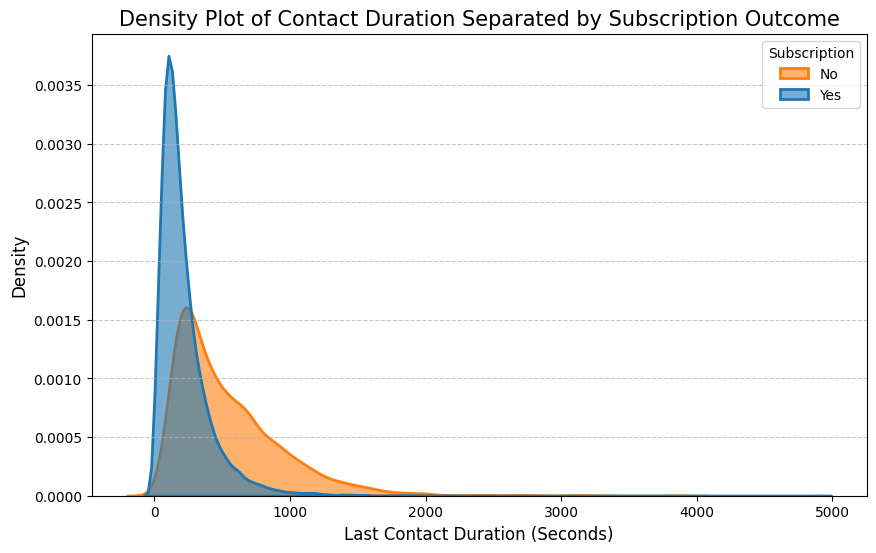

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the density of 'duration' separated by the target 'y'
sns.kdeplot(
    data=df,
    x='duration',
    hue='y',
    fill=True,
    alpha=.6,
    linewidth=2,
    common_norm=False
)

plt.title('Density Plot of Contact Duration Separated by Subscription Outcome', fontsize=15)
plt.xlabel('Last Contact Duration (Seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

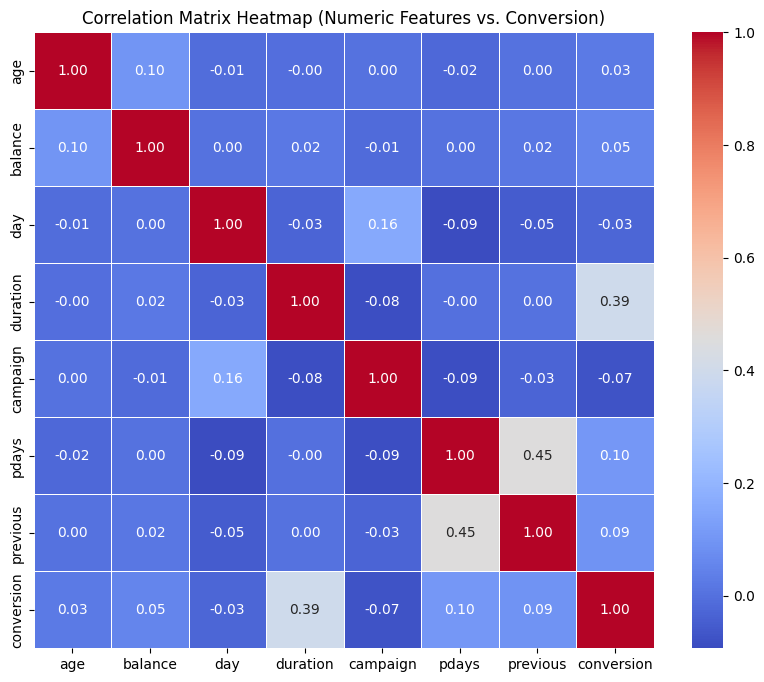

In [ ]:
# Correlation matrix for the numeric features
df['conversion'] = np.where(df['y'] == 'yes',  1, 0)

correlation_columns = numeric_features + ['conversion']
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)

plt.title('Correlation Matrix Heatmap (Numeric Features vs. Conversion)')
plt.show()

In [ ]:
working_df = df.copy()

# Convert all the binary features into 0 and 1 instead of yes and no
for feature in ['default', 'housing', 'loan']:
    working_df[feature] = working_df[feature].map({'yes': 1, 'no': 0})

working_df['conversion'] = np.where(working_df['y'] == 'yes', 1, 0)
working_df['previous_success'] = np.where(working_df['poutcome'] == 'success', 1, 0)
working_df['new_client'] = np.where(working_df['pdays'] == -1, 1, 0)
working_df.loc[working_df['pdays'] == -1, 'pdays'] = 0

binary_features.append('previous_success')
binary_features.append('new_client')
print("New binary features added to working_df and binary_features list.")

New binary features added to working_df and binary_features list.


In [ ]:
# Standardisation
scaler = StandardScaler()
to_scale = working_df[numeric_features]
scaled_df = scaler.fit_transform(to_scale)
working_df[numeric_features] = scaled_df

X_features = numeric_features + binary_features

# Perform One-Hot Encoding on categorical features to convert them to numbers
X_encoded = pd.get_dummies(working_df[X_features + categorical_features],
                           columns=categorical_features,
                           drop_first=True)

In [ ]:
# Split the features
x = X_encoded
y = working_df['conversion']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Check the ratio of negative to possible samples in the dataset
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train ==1)

# Ratio of the number of negative samples vs positive instances
SCALE_POS_WEIGHT = neg_count / pos_count
print(f"Count No - 0: {neg_count}")
print(f"Count Yes - 1: {pos_count}")
print(f"The scale positive weight is: {SCALE_POS_WEIGHT}")



Count No - 0: 31970
Count Yes - 1: 4198
The scale positive weight is: 7.615531205335874


In [ ]:
print(f"Original training set shape: {x_train.shape}")
print(f"Original class distribution: {Counter(y_train)}")

# Initialize SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Fit and resample the training data
x_resampled, y_resampled = smote_enn.fit_resample(x_train.values, y_train)

print(f"Resampled training set shape: {x_resampled.shape}")
print(f"Resampled class distribution: {Counter(y_resampled)}")

Original training set shape: (36168, 33)
Original class distribution: Counter({0: 31970, 1: 4198})
Resampled training set shape: (55961, 33)
Resampled class distribution: Counter({1: 31027, 0: 24934})



--- Model Performance on SMOTEENN Data ---
XGBoost Accuracy: 0.87
XGBoost Precision: 0.48
XGBoost Recall: 0.73
XGBoost F1 Score: 0.58

               precision    recall  f1-score   support

           0       0.96      0.89      0.93      7952
           1       0.48      0.73      0.58      1091

    accuracy                           0.87      9043
   macro avg       0.72      0.81      0.75      9043
weighted avg       0.90      0.87      0.88      9043



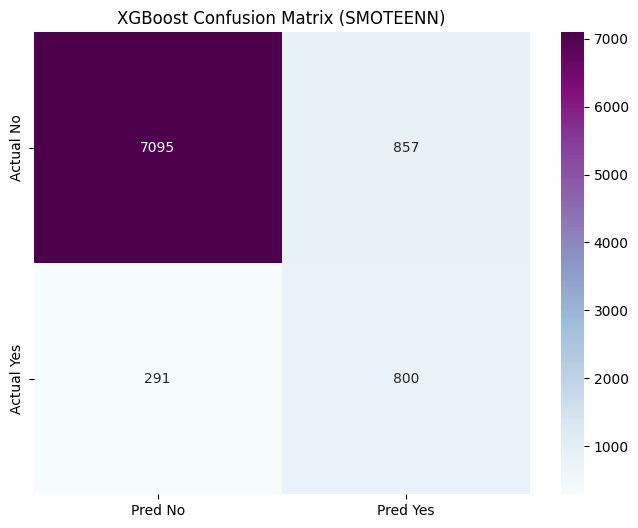

In [ ]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators = 400,
    max_depth = 15,
)

# Fit on the balanced (resampled) data
xgb_model.fit(x_resampled, y_resampled)

# Predict probabilities using the original test set
y_pred_prob = xgb_model.predict_proba(x_test.values)[:, 1]

# Check the probabilty based on the threshold decided
probability_of_conversion = 0.65
y_pred_threshold_xgb = (y_pred_prob >= probability_of_conversion).astype(int)

# Evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_threshold_xgb)
precision_xgb = precision_score(y_test, y_pred_threshold_xgb)
recall_xgb = recall_score(y_test, y_pred_threshold_xgb)
f1_xgb = f1_score(y_test, y_pred_threshold_xgb)

print("\n--- Model Performance on SMOTEENN Data ---")
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")
print(f"XGBoost Precision: {precision_xgb:.2f}")
print(f"XGBoost Recall: {recall_xgb:.2f}")
print(f"XGBoost F1 Score: {f1_xgb:.2f}")

print("\n", classification_report(y_test, y_pred_threshold_xgb))

confusion = confusion_matrix(y_test, y_pred_threshold_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, cmap="BuPu", fmt='d', xticklabels=['Pred No', 'Pred Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title("XGBoost Confusion Matrix (SMOTEENN)")
plt.show()

Training SVC model. This may take longer than the ensemble models.
SVC Training Complete.

--- Model Performance on SMOTEENN Data (SVC) ---
SVC Accuracy: 0.82
SVC Precision: 0.39
SVC Recall: 0.82
SVC F1 Score: 0.53

               precision    recall  f1-score   support

           0       0.97      0.82      0.89      7952
           1       0.39      0.82      0.53      1091

    accuracy                           0.82      9043
   macro avg       0.68      0.82      0.71      9043
weighted avg       0.90      0.82      0.85      9043



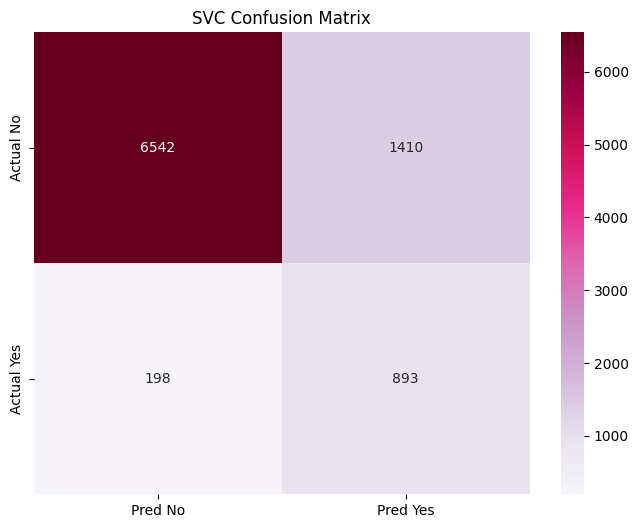

In [ ]:
svc_model = SVC(
    kernel='rbf',
    random_state=42,
    probability=True,
)

# Takes around 7-9 minutes to run
print("Training SVC model. This may take longer than the ensemble models.")
svc_model.fit(x_resampled, y_resampled)
print("SVC Training Complete.")

# Predict probabilities using the original test set
y_pred_prob_svc = svc_model.predict_proba(x_test.values)[:, 1]

# Check the probabilty based on the threshold decided
probability_of_conversion = 0.65
y_pred_threshold_svc = (y_pred_prob_svc >= probability_of_conversion).astype(int)

# Evaluation metrics
accuracy_svc = accuracy_score(y_test, y_pred_threshold_svc)
precision_svc = precision_score(y_test, y_pred_threshold_svc)
recall_svc = recall_score(y_test, y_pred_threshold_svc)
f1_svc = f1_score(y_test, y_pred_threshold_svc)

print("\n--- Model Performance on SMOTEENN Data (SVC) ---")
print(f"SVC Accuracy: {accuracy_svc:.2f}")
print(f"SVC Precision: {precision_svc:.2f}")
print(f"SVC Recall: {recall_svc:.2f}")
print(f"SVC F1 Score: {f1_svc:.2f}")

print("\n", classification_report(y_test, y_pred_threshold_svc))

confusion_svc = confusion_matrix(y_test, y_pred_threshold_svc)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_svc, annot=True, cmap="PuRd", fmt='d', xticklabels=['Pred No', 'Pred Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title("SVC Confusion Matrix")
plt.show()

In [ ]:
# Check how likely someone with loans would be to subscribe to a term deposit plan
loan_client_mask = (
    (x_test['loan'] == 1) |
    (x_test['housing'] == 1) |
    (x_test['default'] == 1)
)

x_test_loans = x_test[loan_client_mask]

print(f"Total clients in the test set with loans/default: {x_test_loans.shape[0]}")

loan_probs_xgb = y_pred_threshold_xgb
loan_probs_svc = y_pred_prob_svc

predicted_subscribers_xgb = np.sum(loan_probs_xgb >= probability_of_conversion)
total_loan_clients_xgb = len(loan_probs_xgb)

predicted_subscribers_svc = np.sum(loan_probs_svc >= probability_of_conversion)
total_loan_clients_svc = len(loan_probs_svc)

prediction_rate_xgb = (predicted_subscribers_xgb / total_loan_clients_xgb) * 100

print(f"\nPredicted Subscription Rate for Clients with Loans - XGBoost: {prediction_rate_xgb:.2f}%")

prediction_rate_svc = (predicted_subscribers_svc / total_loan_clients_svc) * 100

print(f"\nPredicted Subscription Rate for Clients with Loans - SVC: {prediction_rate_svc:.2f}%")


Total clients in the test set with loans/default: 5616

Predicted Subscription Rate for Clients with Loans - XGBoost: 18.32%

Predicted Subscription Rate for Clients with Loans - SVC: 25.47%


/tmp/ipython-input-3408532174.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


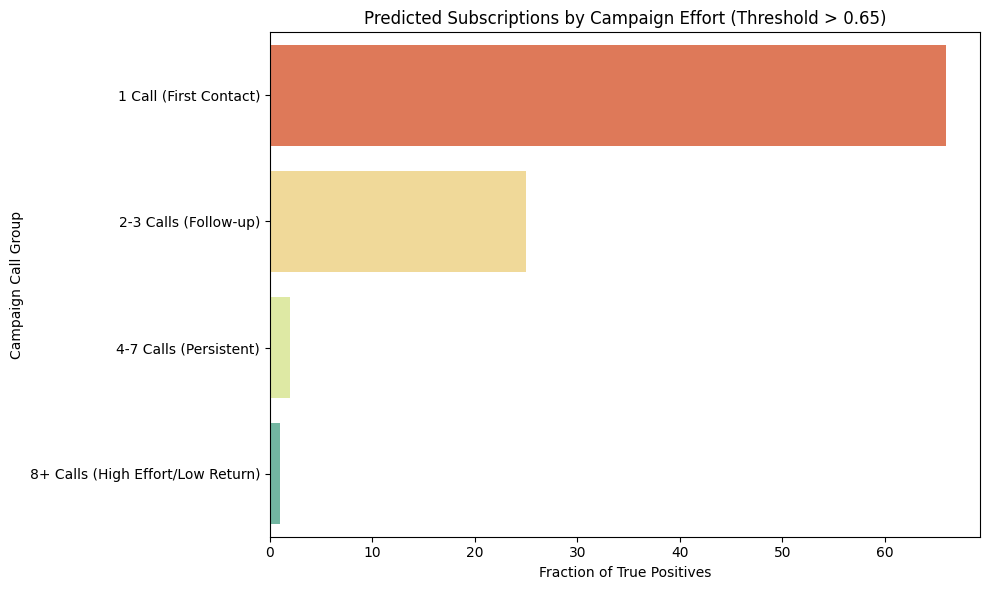

In [ ]:
prediction_df = pd.DataFrame({
    'Campaign_Calls': working_df.loc[x_test.index, 'campaign'].reset_index(drop=True),
    'Predicted_Subscription': y_pred_threshold_xgb
})


# Create group for checking how many calls before subscription (predicted)
def group_campaign_calls(calls):
    """Groups campaign call counts into defined bins for analysis."""
    calls = int(calls)
    if calls == 1:
        return '1 Call (First Contact)'
    elif 2 <= calls <= 3:
        return '2-3 Calls (Follow-up)'
    elif 4 <= calls <= 7:
        return '4-7 Calls (Persistent)'
    elif calls >= 8:
        return '8+ Calls (High Effort/Low Return)'
    else:
        return 'Other'

prediction_df['Call_Group'] = prediction_df['Campaign_Calls'].apply(group_campaign_calls)


campaign_results_grouped = prediction_df.groupby('Call_Group')['Predicted_Subscription'].sum().reset_index()

campaign_results_grouped.columns = ['Call Group', 'Predicted Subscriptions']

# Generate the correct order
order = ['1 Call (First Contact)', '2-3 Calls (Follow-up)', '4-7 Calls (Persistent)', '8+ Calls (High Effort/Low Return)']
campaign_results_grouped['Call Group'] = pd.Categorical(campaign_results_grouped['Call Group'], categories=order, ordered=True)
campaign_results_grouped = campaign_results_grouped.sort_values('Call Group', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Predicted Subscriptions',
    y='Call Group',
    data=campaign_results_grouped,
    orient='h',
    palette='Spectral'
)
plt.title(f'Predicted Subscriptions by Campaign Effort (Threshold > {probability_of_conversion:.2f})')
plt.xlabel('Fraction of True Positives')
plt.ylabel('Campaign Call Group')
plt.tight_layout()
plt.show()

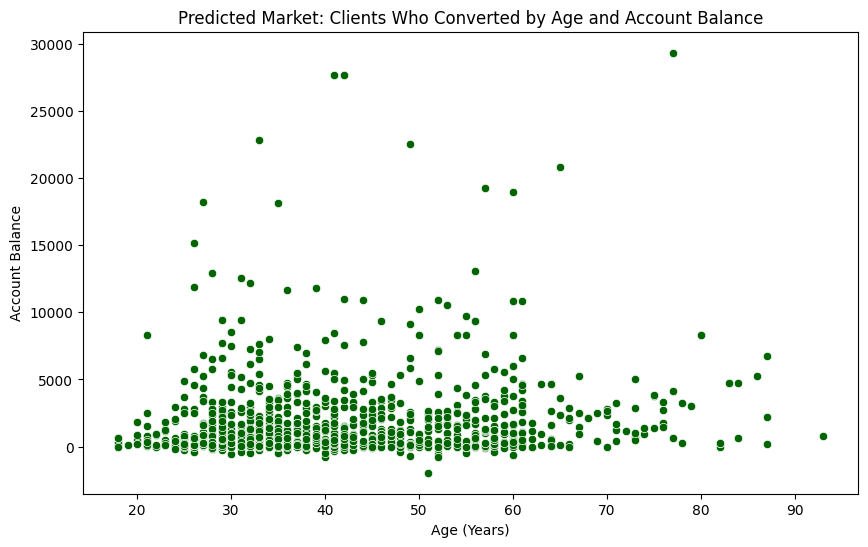

In [ ]:
# See how age and balance affect the predicted y
plot_df = df.loc[x_test.index, ['age', 'balance']].copy()

plot_df['conversion'] = y_test

subscribers_df = plot_df[plot_df['conversion'] == 1].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='age',
    y='balance',
    data=subscribers_df,
    color='darkgreen',
)

plt.title('Predicted Market: Clients Who Converted by Age and Account Balance')
plt.xlabel('Age (Years)')
plt.ylabel('Account Balance')
plt.show()

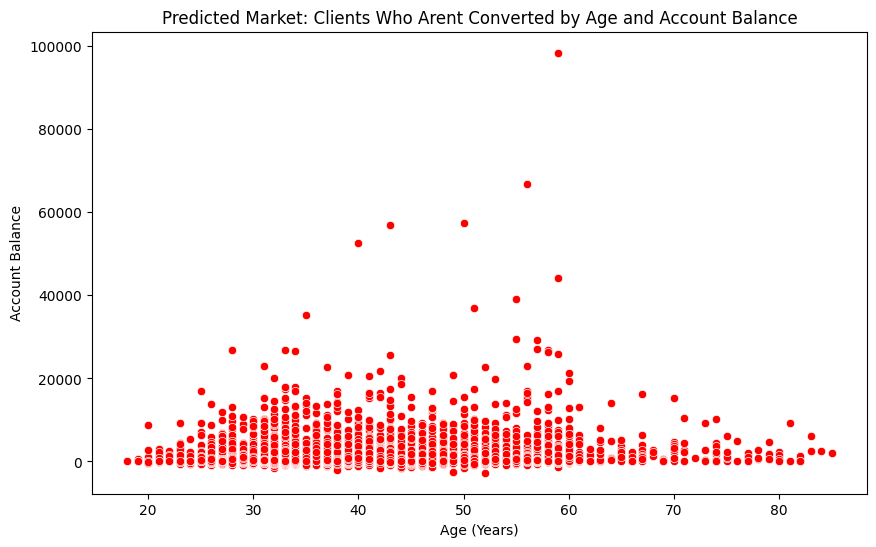

In [ ]:
# See how age and balance affect the predicted y
plot_df = df.loc[x_test.index, ['age', 'balance']].copy()

plot_df['conversion'] = y_test

not_subscribers_df = plot_df[plot_df['conversion'] == 0].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='age',
    y='balance',
    data=not_subscribers_df,
    color='red',
)

plt.title('Predicted Market: Clients Who Arent Converted by Age and Account Balance')
plt.xlabel('Age (Years)')
plt.ylabel('Account Balance')
plt.show()

/tmp/ipython-input-1015159056.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


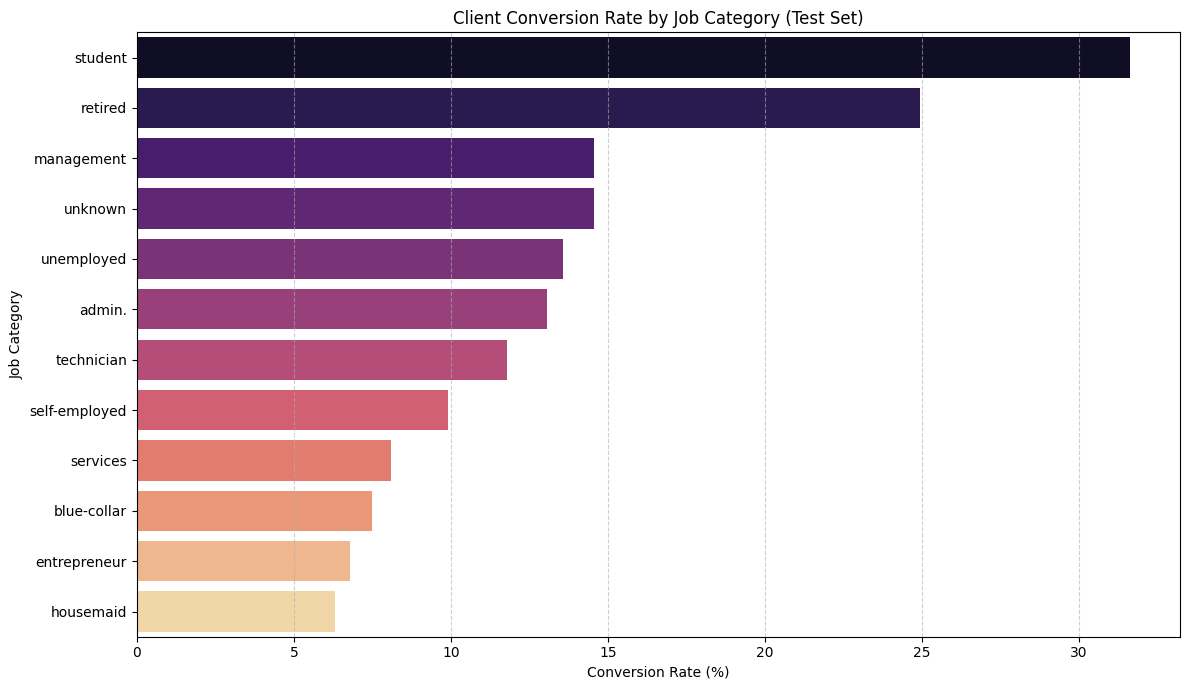

In [ ]:
# See how job affect the predicted y
job_analysis_df = df.loc[x_test.index, ['job']].copy()

job_analysis_df['conversion'] = y_test

job_conversion_rate = job_analysis_df.groupby('job')['conversion'].mean().reset_index()

job_conversion_rate.columns = ['Job Category', 'Conversion Rate']
job_conversion_rate['Conversion Rate'] = job_conversion_rate['Conversion Rate'] * 100

job_conversion_rate = job_conversion_rate.sort_values(by='Conversion Rate', ascending=False)


plt.figure(figsize=(12, 7))
sns.barplot(
    x='Conversion Rate',
    y='Job Category',
    data=job_conversion_rate,
    palette='magma'
)

plt.title('Client Conversion Rate by Job Category (Test Set)')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Job Category')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()